# Phase 5: CNN Classifier Training (ResNet-50 vs EfficientNet-B0)

This notebook trains and evaluates two CNN architectures to classify SEM defect crops into 3 classes:
0: Inclusion-Particle, 1: Porosity, 2: Tear-Delamination.

It is designed to run on a Google Colab GPU and persist all checkpoints and metrics to Google Drive.

In [11]:
# 1. Setup & Environment Audit
!pip install torch torchvision pandas matplotlib seaborn scikit-learn > /dev/null 2>&1
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import time

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [12]:
# 2. Mount Google Drive & Locate / Extract Classifier Dataset
import zipfile
import shutil

if os.path.exists('/content/drive/MyDrive'):
    print("✅ Google Drive is already mounted.")
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("✅ Google Drive successfully mounted.")
    except Exception as e:
        print("⚠️ Remote Colab UI auth blocked. Please mount Drive manually using the Colab left sidebar -> Files -> Mount Drive.")

PROJECT_ROOT = '/content/drive/MyDrive/sem_defect_project'
RUNS_DIR = f"{PROJECT_ROOT}/runs/classify"
os.makedirs(RUNS_DIR, exist_ok=True)

# Smart Dataset Detection:
# Fast local path in Colab for superior PyTorch DataLoader throughput:
LOCAL_DATASET = '/content/classifier_crops'

possible_zips = [
    '/content/classifier_crops.zip',
    f"{PROJECT_ROOT}/classifier_crops.zip",
    f"{PROJECT_ROOT}/datasets/classifier_crops.zip",
    '/content/drive/MyDrive/classifier_crops.zip'
]

possible_folders = [
    LOCAL_DATASET,
    f"{PROJECT_ROOT}/datasets/classifier_crops",
    f"{PROJECT_ROOT}/classifier_crops"
]

DATASET_ROOT = None

# 1. Check if already extracted locally
if os.path.exists(os.path.join(LOCAL_DATASET, 'train')):
    DATASET_ROOT = LOCAL_DATASET
    print(f"✅ Found local fast dataset at: {DATASET_ROOT}")
else:
    # 2. Check for zip file to extract locally (10x faster training than Drive FUSE mount)
    zip_found = None
    for zp in possible_zips:
        if os.path.exists(zp):
            zip_found = zp
            break
    
    if zip_found:
        print(f"📦 Extracting {zip_found} to /content/ for fast GPU training...")
        with zipfile.ZipFile(zip_found, 'r') as zip_ref:
            zip_ref.extractall('/content')
        if os.path.exists(os.path.join(LOCAL_DATASET, 'train')):
            DATASET_ROOT = LOCAL_DATASET
        elif os.path.exists('/content/train'):
            DATASET_ROOT = '/content'
        print(f"✅ Extracted! Active dataset at: {DATASET_ROOT}")
    else:
        # 3. Check for existing folders in Drive
        for fp in possible_folders:
            if os.path.exists(os.path.join(fp, 'train')):
                print(f"📁 Found dataset folder at {fp}. Copying to local fast SSD {LOCAL_DATASET}...")
                shutil.copytree(fp, LOCAL_DATASET, dirs_exist_ok=True)
                DATASET_ROOT = LOCAL_DATASET
                print(f"✅ Ready! Active dataset at: {DATASET_ROOT}")
                break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        f"❌ Classifier dataset not found!\n\n"
        f"Please upload 'classifier_crops.zip' (27 MB) using either:\n"
        f"  1. Upload to Google Drive at: {PROJECT_ROOT}/classifier_crops.zip\n"
        f"  2. Or drag & drop directly into Colab's left sidebar 'Files' tab (/content/classifier_crops.zip)\n"
    )

print(f"🎯 Active Dataset Directory: {DATASET_ROOT}")
print(f"📁 Runs Directory: {RUNS_DIR}")

✅ Google Drive is already mounted.
✅ Found local fast dataset at: /content/classifier_crops
🎯 Active Dataset Directory: /content/classifier_crops
📁 Runs Directory: /content/drive/MyDrive/sem_defect_project/runs/classify


In [13]:
# 3. Dataset Verification & Sanity Checks
splits = ['train', 'valid', 'test']
class_counts = {}

print("--- DATASET SANITY CHECK ---")
for split in splits:
    split_dir = os.path.join(DATASET_ROOT, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"{split_dir} not found!")
    
    print(f"\nSplit: {split}")
    split_total = 0
    for cls_name in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls_name)
        if os.path.isdir(cls_dir):
            count = len(os.listdir(cls_dir))
            split_total += count
            if split == 'train':
                class_counts[cls_name] = count
            print(f"  {cls_name}: {count} images")
    print(f"  TOTAL {split}: {split_total}")

if 'train' in splits:
    total_train = sum(class_counts.values())
    weights = [total_train / class_counts[c] for c in class_counts.keys()]
    # Normalize weights so the minimum weight is 1.0
    min_w = min(weights)
    class_weights = torch.FloatTensor([w / min_w for w in weights]).to(device)
    
    print(f"\nCalculated Class Weights for CrossEntropyLoss:")
    for cls_name, w in zip(class_counts.keys(), class_weights):
        print(f"  {cls_name}: {w.item():.4f}")

--- DATASET SANITY CHECK ---

Split: train
  Inclusion-Particle: 1585 images
  Porosity: 2174 images
  Tear-Delamination: 877 images
  TOTAL train: 4636

Split: valid
  Inclusion-Particle: 49 images
  Porosity: 93 images
  Tear-Delamination: 42 images
  TOTAL valid: 184

Split: test
  Inclusion-Particle: 38 images
  Porosity: 61 images
  Tear-Delamination: 23 images
  TOTAL test: 122

Calculated Class Weights for CrossEntropyLoss:
  Inclusion-Particle: 1.3716
  Porosity: 1.0000
  Tear-Delamination: 2.4789


In [14]:
# 4. Data Augmentation Policy
"""
AUGMENTATION JUSTIFICATION:
SEM topography does not have a strict gravity/up-down orientation like natural images.
Therefore, H-Flips, V-Flips, and slight rotations are physically valid and preserve defect morphology.
We avoid heavy color jitter or blurring to preserve the structural contrast that differentiates porosity from tears.
"""
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_ROOT, 'train'), transform=train_transform)
valid_dataset = datasets.ImageFolder(os.path.join(DATASET_ROOT, 'valid'), transform=val_test_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_ROOT, 'test'), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['Inclusion-Particle', 'Porosity', 'Tear-Delamination']


In [15]:
# 5. Training Engine Definition
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=30, patience=7):
    exp_dir = os.path.join(RUNS_DIR, model_name)
    os.makedirs(exp_dir, exist_ok=True)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        val_loss = val_loss / len(valid_dataset)
        val_acc = val_corrects.double() / len(valid_dataset)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(exp_dir, 'best.pt'))
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered!")
                break
                
    torch.save(model.state_dict(), os.path.join(exp_dir, 'last.pt'))
    
    with open(os.path.join(exp_dir, 'history.json'), 'w') as f:
        json.dump(history, f, indent=4)
        
    print(f"Training complete in {(time.time() - start_time)/60:.2f} minutes.")
    return history

In [16]:
# 6. Evaluation Function Definition
def evaluate_model(model, model_name, dataloader, dataset_name="test"):
    exp_dir = os.path.join(RUNS_DIR, model_name)
    model.load_state_dict(torch.load(os.path.join(exp_dir, 'best.pt')))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print(f"\nClassification Report ({dataset_name}):")
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print(report)
    
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    with open(os.path.join(exp_dir, f'{dataset_name}_metrics.json'), 'w') as f:
        json.dump(report_dict, f, indent=4)
        
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {model_name} on {dataset_name} set')
    plt.savefig(os.path.join(exp_dir, f'{dataset_name}_confusion_matrix.png'))
    plt.show()

---
### **PHASE 5 APPROVED: MODEL TRAINING & COMPARISON**
Executing training for ResNet-50 and EfficientNet-B0 according to the approved Phase 5 plan.
---


--- Initializing ResNet-50 ---
Starting ResNet-50 Training...
Epoch 1/40 - Train Loss: 0.5078 Acc: 0.7966 | Val Loss: 0.4061 Acc: 0.8424
Epoch 2/40 - Train Loss: 0.3430 Acc: 0.8779 | Val Loss: 0.3832 Acc: 0.8424
Epoch 3/40 - Train Loss: 0.2888 Acc: 0.8978 | Val Loss: 0.5808 Acc: 0.8207
Epoch 4/40 - Train Loss: 0.2386 Acc: 0.9161 | Val Loss: 0.4790 Acc: 0.8424
Epoch 5/40 - Train Loss: 0.2359 Acc: 0.9124 | Val Loss: 0.4047 Acc: 0.8859
Epoch 6/40 - Train Loss: 0.2234 Acc: 0.9234 | Val Loss: 0.4821 Acc: 0.8804
Epoch 7/40 - Train Loss: 0.1729 Acc: 0.9368 | Val Loss: 0.4310 Acc: 0.8533
Epoch 8/40 - Train Loss: 0.1531 Acc: 0.9454 | Val Loss: 0.3659 Acc: 0.8641
Epoch 9/40 - Train Loss: 0.1465 Acc: 0.9454 | Val Loss: 0.4017 Acc: 0.8478
Epoch 10/40 - Train Loss: 0.1350 Acc: 0.9500 | Val Loss: 0.5207 Acc: 0.8207
Epoch 11/40 - Train Loss: 0.1361 Acc: 0.9530 | Val Loss: 0.3663 Acc: 0.8696
Epoch 12/40 - Train Loss: 0.1267 Acc: 0.9551 | Val Loss: 0.4424 Acc: 0.8696
Epoch 13/40 - Train Loss: 0.1099 A

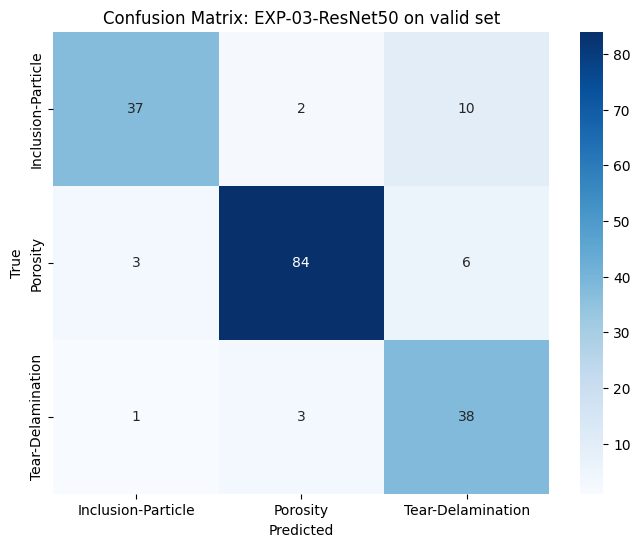


Classification Report (test):
                    precision    recall  f1-score   support

Inclusion-Particle     0.8205    0.8421    0.8312        38
          Porosity     0.9434    0.8197    0.8772        61
 Tear-Delamination     0.7333    0.9565    0.8302        23

          accuracy                         0.8525       122
         macro avg     0.8324    0.8728    0.8462       122
      weighted avg     0.8655    0.8525    0.8540       122



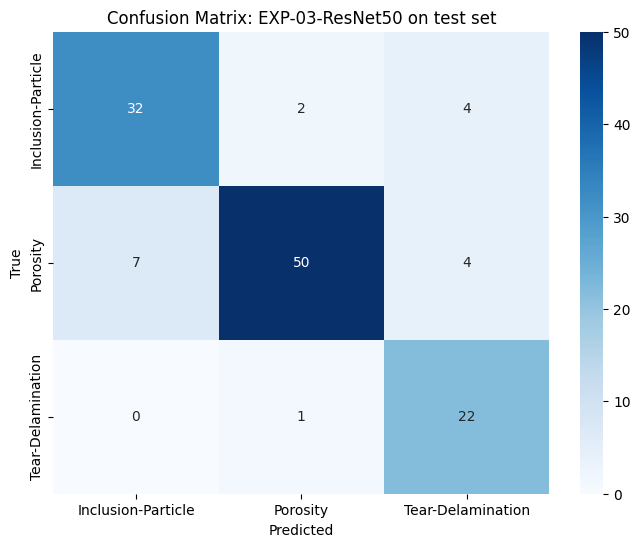

In [17]:
# 7. ResNet-50 Training (EXP-03-ResNet50)
print("\n--- Initializing ResNet-50 ---")
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers except the last block
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.layer4.parameters():
    param.requires_grad = True

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 3)
)
resnet = resnet.to(device)

# Using Weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Starting ResNet-50 Training...")
history_resnet = train_model(resnet, "EXP-03-ResNet50", criterion, optimizer, scheduler, num_epochs=40, patience=7)

print("\n--- Evaluating ResNet-50 ---")
evaluate_model(resnet, "EXP-03-ResNet50", valid_loader, "valid")
evaluate_model(resnet, "EXP-03-ResNet50", test_loader, "test")



--- Initializing EfficientNet-B0 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]


Starting EfficientNet-B0 Training...
Epoch 1/40 - Train Loss: 0.8202 Acc: 0.6290 | Val Loss: 0.6315 Acc: 0.7717
Epoch 2/40 - Train Loss: 0.5488 Acc: 0.7798 | Val Loss: 0.5913 Acc: 0.7609
Epoch 3/40 - Train Loss: 0.4637 Acc: 0.8199 | Val Loss: 0.4940 Acc: 0.8043
Epoch 4/40 - Train Loss: 0.4161 Acc: 0.8335 | Val Loss: 0.5480 Acc: 0.7880
Epoch 5/40 - Train Loss: 0.3746 Acc: 0.8568 | Val Loss: 0.6625 Acc: 0.7717
Epoch 6/40 - Train Loss: 0.3568 Acc: 0.8671 | Val Loss: 0.5522 Acc: 0.7935
Epoch 7/40 - Train Loss: 0.3336 Acc: 0.8788 | Val Loss: 0.6004 Acc: 0.7826
Epoch 8/40 - Train Loss: 0.3294 Acc: 0.8805 | Val Loss: 0.6349 Acc: 0.7935
Epoch 9/40 - Train Loss: 0.3121 Acc: 0.8859 | Val Loss: 0.6305 Acc: 0.7989
Epoch 10/40 - Train Loss: 0.3057 Acc: 0.8881 | Val Loss: 0.5592 Acc: 0.8152
Early stopping triggered!
Training complete in 2.26 minutes.

--- Evaluating EfficientNet-B0 ---

Classification Report (valid):
                    precision    recall  f1-score   support

Inclusion-Particle    

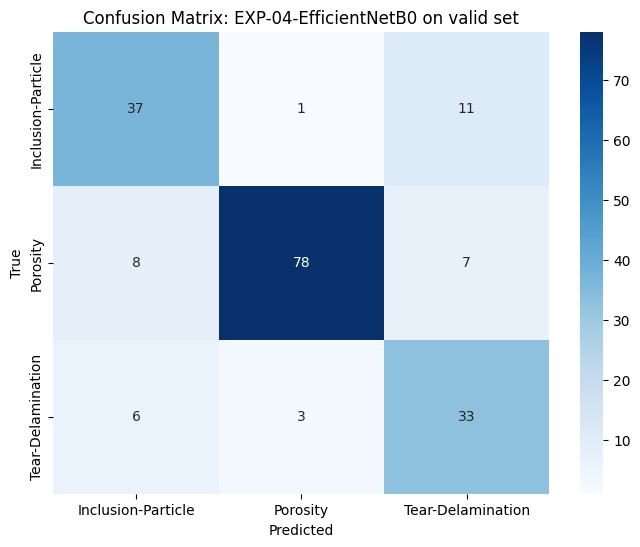


Classification Report (test):
                    precision    recall  f1-score   support

Inclusion-Particle     0.9118    0.8158    0.8611        38
          Porosity     0.9123    0.8525    0.8814        61
 Tear-Delamination     0.6452    0.8696    0.7407        23

          accuracy                         0.8443       122
         macro avg     0.8231    0.8459    0.8277       122
      weighted avg     0.8618    0.8443    0.8485       122



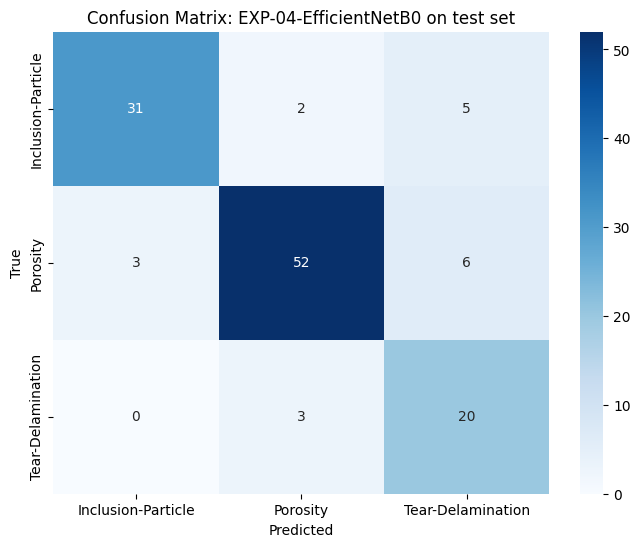

In [18]:
# 8. EfficientNet-B0 Training (EXP-04-EfficientNetB0)
print("\n--- Initializing EfficientNet-B0 ---")
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers except the last few blocks
for param in effnet.parameters():
    param.requires_grad = False
for param in effnet.features[7:].parameters():
    param.requires_grad = True

num_ftrs = effnet.classifier[1].in_features
effnet.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 3)
)
effnet = effnet.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, effnet.parameters()), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Starting EfficientNet-B0 Training...")
history_effnet = train_model(effnet, "EXP-04-EfficientNetB0", criterion, optimizer, scheduler, num_epochs=40, patience=7)

print("\n--- Evaluating EfficientNet-B0 ---")
evaluate_model(effnet, "EXP-04-EfficientNetB0", valid_loader, "valid")
evaluate_model(effnet, "EXP-04-EfficientNetB0", test_loader, "test")
